# 01. 금융 시계열 데이터 수집·정제 및 품질 검증

## 분석 목적

본 노트북은 2010년 1월부터 2024년 12월까지의 월별 금융 시계열을 수집·정제하여 KOSPI 거시경제 결정요인 분석에 사용할 기초 데이터셋을 구축한다.

단순히 데이터를 병합하는 데 그치지 않고, 각 변수의 수집 범위와 결측 발생 원인을 확인하고 원천 데이터의 품질을 검증한다. 정상성 검정과 회귀분석은 이후 파일에서 별도로 수행한다.

## 사용 데이터

| 변수      | 역할   | 출처         |
| --------- | ---- | ------------- |
| KOSPI     | 종속변수 | Yahoo Finance |
| S&P 500   | 설명변수 | Yahoo Finance |
| 원/달러 환율  | 설명변수 | Yahoo Finance |
| WTI 원유 가격 | 설명변수 | Yahoo Finance  |
| 국고채 3년 금리 | 설명변수 | 한국은행 ECOS    |

국고채 3년 금리는 `data/raw/interest_rate.csv`에 저장된 ECOS 원본 CSV를 사용하며, 나머지 금융시장 변수는 `yfinance`를 통해 수집한다.

## 처리 절차

1. `config.yaml`에서 분석 기간, 티커 및 파일 경로를 불러온다.
2. 프로젝트 루트를 자동 탐색한다.
3. Yahoo Finance 금융 데이터를 수집하고 월별 인덱스로 정리한다.
4. ECOS 국고채 3년 금리 CSV의 날짜와 금리 값을 파싱한다.
5. 변수별 날짜 범위, 중복, 결측치 및 비정상 값을 점검한다.
6. 결측 날짜와 발생 원인을 확인한 뒤 근거가 있는 처리 방식만 적용한다.
7. 최종 분석 데이터와 데이터 품질 점검 결과를 저장한다.

## 주요 산출물

* `data/processed/kospi_macro_monthly.csv`
* `outputs/reports/data_quality_summary.csv`
* `outputs/figures/monthly_series_standardized.png`

> 수준 변수의 정상성 여부와 차분 필요성은 `02_stationarity_diagnostics.ipynb`에서 ADF 및 KPSS 검정을 통해 판단한다.


## 0. 패키지 불러오기 및 프로젝트 경로 설정

In [1]:
from __future__ import annotations

import csv
import re
import sys
from datetime import datetime
from pathlib import Path
from typing import Dict, List, Optional
from zoneinfo import ZoneInfo

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml

plt.rcParams["axes.unicode_minus"] = False


def find_project_root(start: Path | None = None) -> Path:
    """config.yaml이 위치한 프로젝트 최상위 경로를 탐색한다."""
    start = Path.cwd() if start is None else Path(start).resolve()

    for candidate in [start, *start.parents]:
        if (candidate / "config.yaml").is_file():
            return candidate

    raise FileNotFoundError(
        "config.yaml을 찾지 못했습니다. "
        "현재 노트북이 프로젝트 폴더 내부에 있는지 확인하세요."
    )


ROOT = find_project_root()

KST = ZoneInfo("Asia/Seoul")
RUN_TIMESTAMP = datetime.now(KST)

print(f"[INFO] Project root: {ROOT}")
print(f"[INFO] Run timestamp (KST): {RUN_TIMESTAMP:%Y-%m-%d %H:%M:%S}")
print(f"[INFO] Python version: {sys.version.split()[0]}")

[INFO] Project root: c:\Users\user\Desktop\주진호\05.ICT 인턴십\01.KOSPI
[INFO] Run timestamp (KST): 2026-06-27 07:56:24
[INFO] Python version: 3.13.3


## 1. 설정 파일 불러오기

In [2]:
def load_config(root: Path) -> Dict:
    """config.yaml을 읽고 필수 설정 항목을 검증한다."""
    config_path = root / "config.yaml"

    if not config_path.is_file():
        raise FileNotFoundError(f"설정 파일을 찾지 못했습니다: {config_path}")

    with open(config_path, "r", encoding="utf-8") as file:
        config = yaml.safe_load(file)

    if not isinstance(config, dict):
        raise ValueError("config.yaml의 최상위 구조가 올바르지 않습니다.")

    required_sections = [
        "data",
        "period",
        "yfinance_tickers",
        "model",
        "diagnostics",
    ]

    missing_sections = [
        section for section in required_sections
        if section not in config
    ]

    if missing_sections:
        raise KeyError(
            f"config.yaml에 필수 섹션이 없습니다: {missing_sections}"
        )

    required_data_keys = [
        "raw_dir",
        "processed_dir",
        "interest_rate_file",
        "final_dataset_file",
    ]

    missing_data_keys = [
        key for key in required_data_keys
        if key not in config["data"]
    ]

    if missing_data_keys:
        raise KeyError(
            f"config.yaml의 data 섹션에 필수 항목이 없습니다: "
            f"{missing_data_keys}"
        )

    return config


cfg = load_config(ROOT)

raw_dir = ROOT / cfg["data"]["raw_dir"]
processed_dir = ROOT / cfg["data"]["processed_dir"]

fig_dir = ROOT / "outputs" / "figures"
metric_dir = ROOT / "outputs" / "metrics"
report_dir = ROOT / "outputs" / "reports"

interest_rate_path = raw_dir / cfg["data"]["interest_rate_file"]
final_dataset_path = processed_dir / cfg["data"]["final_dataset_file"]

for directory in [
    raw_dir,
    processed_dir,
    fig_dir,
    metric_dir,
    report_dir,
]:
    directory.mkdir(parents=True, exist_ok=True)

if not interest_rate_path.is_file():
    raise FileNotFoundError(
        "ECOS 국고채 3년 금리 원본 파일을 찾지 못했습니다.\n"
        f"예상 경로: {interest_rate_path}"
    )

start_month = pd.Timestamp(
    cfg["period"]["start"]
).to_period("M")

end_month = pd.Timestamp(
    cfg["period"]["end"]
).to_period("M")

expected_months = len(
    pd.period_range(start_month, end_month, freq="M")
)

print(f"[INFO] Project name: {cfg['project']['name']}")
print(
    f"[INFO] Analysis period: "
    f"{cfg['period']['start']} ~ {cfg['period']['end']}"
)
print(f"[INFO] Expected monthly observations: {expected_months}")
print(f"[INFO] Interest-rate source: {interest_rate_path}")
print(f"[INFO] Final dataset path: {final_dataset_path}")
print(f"[INFO] Tickers: {cfg['yfinance_tickers']}")

[INFO] Project name: 주진호_포트폴리오03_KOSPI결정요인분석
[INFO] Analysis period: 2010-01-01 ~ 2024-12-31
[INFO] Expected monthly observations: 180
[INFO] Interest-rate source: c:\Users\user\Desktop\주진호\05.ICT 인턴십\01.KOSPI\data\raw\interest_rate.csv
[INFO] Final dataset path: c:\Users\user\Desktop\주진호\05.ICT 인턴십\01.KOSPI\data\processed\kospi_macro_monthly.csv
[INFO] Tickers: {'KOSPI': '^KS11', 'SP500': '^GSPC', 'Exchange_Rate': 'KRW=X', 'WTI_Oil': 'CL=F'}


## 2. yfinance 일별 금융 데이터 수집 및 월말값 생성

Yahoo Finance의 월별 직접 다운로드 과정에서 일부 월이 누락될 가능성을 줄이기 위해 일별 종가를 수집한다. 이후 각 월의 마지막 유효 거래일 종가를 선택하여 월별 시계열로 변환한다.

각 변수는 2010년 1월부터 2024년 12월까지의 기대 월 인덱스와 대조하여 수집 기간, 관측치 수, 결측 월을 점검한다.

In [3]:
def import_yfinance():
    """yfinance를 불러오고, 설치되지 않은 경우 명확한 오류를 반환한다."""
    try:
        import yfinance as yf
        return yf
    except ImportError as exc:
        raise ImportError(
            "yfinance가 설치되어 있지 않습니다. "
            "`pip install yfinance`를 실행하세요."
        ) from exc


def extract_close_price(downloaded: pd.DataFrame) -> pd.Series:
    """
    yfinance 다운로드 결과에서 종가(Close)를 추출한다.

    yfinance 버전에 따라 일반 컬럼 또는 MultiIndex 컬럼으로
    반환될 수 있으므로 두 구조를 모두 처리한다.
    """
    if downloaded.empty:
        raise ValueError("Yahoo Finance 다운로드 결과가 비어 있습니다.")

    preferred_fields = ["Close", "Adj Close"]

    if isinstance(downloaded.columns, pd.MultiIndex):
        price = None

        for field in preferred_fields:
            if field in downloaded.columns.get_level_values(0):
                extracted = downloaded.xs(field, axis=1, level=0)
                price = (
                    extracted.iloc[:, 0]
                    if isinstance(extracted, pd.DataFrame)
                    else extracted
                )
                break

            if field in downloaded.columns.get_level_values(1):
                extracted = downloaded.xs(field, axis=1, level=1)
                price = (
                    extracted.iloc[:, 0]
                    if isinstance(extracted, pd.DataFrame)
                    else extracted
                )
                break

        if price is None:
            raise ValueError(
                "다운로드 결과에서 Close 또는 Adj Close를 찾지 못했습니다."
            )

    else:
        price = None

        for field in preferred_fields:
            if field in downloaded.columns:
                price = downloaded[field]
                break

        if price is None:
            raise ValueError(
                "다운로드 결과에서 Close 또는 Adj Close를 찾지 못했습니다."
            )

    return pd.to_numeric(price, errors="coerce")


def convert_daily_to_monthly(
    daily_price: pd.Series,
    expected_index: pd.DatetimeIndex,
    variable_name: str,
) -> pd.Series:
    """
    일별 종가에서 각 월의 마지막 유효 거래일 값을 선택하고,
    전체 기대 월 인덱스에 맞춰 재색인한다.
    """
    price = daily_price.copy()
    price.index = pd.to_datetime(price.index)

    if isinstance(price.index, pd.DatetimeIndex):
        price.index = price.index.tz_localize(None)

    price = (
        price.replace([np.inf, -np.inf], np.nan)
        .dropna()
        .sort_index()
    )

    if price.empty:
        raise ValueError(
            f"{variable_name}의 유효한 일별 가격 데이터가 없습니다."
        )

    monthly = price.groupby(price.index.to_period("M")).last()
    monthly.index = monthly.index.to_timestamp()
    monthly = monthly.reindex(expected_index)
    monthly.name = variable_name

    return monthly


def download_monthly_yfinance(
    tickers: Dict[str, str],
    start: str,
    end: str,
) -> pd.DataFrame:
    """
    Yahoo Finance에서 일별 종가를 받은 뒤 월말 종가로 변환한다.
    """
    yf = import_yfinance()

    start_timestamp = pd.Timestamp(start)
    end_timestamp = pd.Timestamp(end)

    expected_index = pd.period_range(
        start=start_timestamp.to_period("M"),
        end=end_timestamp.to_period("M"),
        freq="M",
    ).to_timestamp()

    # yfinance의 end는 미포함이므로 마지막 날짜의 다음 날을 전달한다.
    download_end = (
        end_timestamp + pd.Timedelta(days=1)
    ).strftime("%Y-%m-%d")

    monthly_series = []

    for variable_name, ticker in tickers.items():
        print(
            f"\n[INFO] Downloading daily data: "
            f"{variable_name} ({ticker})"
        )

        downloaded = yf.download(
            ticker,
            start=start_timestamp.strftime("%Y-%m-%d"),
            end=download_end,
            interval="1d",
            progress=False,
            auto_adjust=False,
            threads=False,
        )

        daily_price = extract_close_price(downloaded)

        monthly_price = convert_daily_to_monthly(
            daily_price=daily_price,
            expected_index=expected_index,
            variable_name=variable_name,
        )

        missing_months = (
            monthly_price[monthly_price.isna()]
            .index.strftime("%Y-%m")
            .tolist()
        )

        print(
            f"[INFO] {variable_name}: "
            f"{monthly_price.notna().sum()} / "
            f"{len(expected_index)} months collected"
        )
        print(
            f"[INFO] Valid range: "
            f"{monthly_price.first_valid_index()} ~ "
            f"{monthly_price.last_valid_index()}"
        )

        if missing_months:
            print(
                f"[WARN] Missing months ({len(missing_months)}): "
                f"{missing_months}"
            )
        else:
            print("[INFO] Missing months: 0")

        monthly_series.append(monthly_price)

    market_data = pd.concat(monthly_series, axis=1)
    market_data.index.name = "Date"
    market_data = market_data.sort_index()

    return market_data


df_market_raw = download_monthly_yfinance(
    tickers=cfg["yfinance_tickers"],
    start=cfg["period"]["start"],
    end=cfg["period"]["end"],
)

print("\n[INFO] Raw monthly market-data shape:", df_market_raw.shape)
print("\n[INFO] Missing values by variable")
print(df_market_raw.isna().sum())

df_market_raw.head()


[INFO] Downloading daily data: KOSPI (^KS11)
[INFO] KOSPI: 180 / 180 months collected
[INFO] Valid range: 2010-01-01 00:00:00 ~ 2024-12-01 00:00:00
[INFO] Missing months: 0

[INFO] Downloading daily data: SP500 (^GSPC)
[INFO] SP500: 180 / 180 months collected
[INFO] Valid range: 2010-01-01 00:00:00 ~ 2024-12-01 00:00:00
[INFO] Missing months: 0

[INFO] Downloading daily data: Exchange_Rate (KRW=X)
[INFO] Exchange_Rate: 180 / 180 months collected
[INFO] Valid range: 2010-01-01 00:00:00 ~ 2024-12-01 00:00:00
[INFO] Missing months: 0

[INFO] Downloading daily data: WTI_Oil (CL=F)
[INFO] WTI_Oil: 180 / 180 months collected
[INFO] Valid range: 2010-01-01 00:00:00 ~ 2024-12-01 00:00:00
[INFO] Missing months: 0

[INFO] Raw monthly market-data shape: (180, 4)

[INFO] Missing values by variable
KOSPI            0
SP500            0
Exchange_Rate    0
WTI_Oil          0
dtype: int64


,KOSPI,SP500,Exchange_Rate,WTI_Oil
Date,,,,
2010-01-01,1602.430054,1073.869995,1158.199951,72.889999
2010-02-01,1594.579956,1104.489990,1161.400024,79.660004
2010-03-01,1692.849976,1169.430054,1131.599976,83.760002
2010-04-01,1741.560059,1186.689941,1107.900024,86.150002
2010-05-01,1641.250000,1089.410034,1200.000000,73.970001


## 3. 금융시장 데이터 품질 검증

수집된 월별 금융시장 데이터가 분석 기간 전체를 포함하는지 확인하고, 날짜 중복·결측치·무한대·비정상 범위 등을 점검한다.

이 단계에서는 이상값을 자동으로 수정하지 않는다. 먼저 이상 항목을 식별하고, 데이터 출처와 경제적 의미를 검토한 뒤 처리 여부를 결정한다.

In [4]:
def validate_market_data(
    data: pd.DataFrame,
    expected_rows: int,
    expected_columns: List[str],
) -> pd.DataFrame:
    """금융시장 월별 데이터의 구조와 품질을 검증한다."""
    expected_index = pd.period_range(
        start=start_month,
        end=end_month,
        freq="M",
    ).to_timestamp()

    missing_months = expected_index.difference(data.index)
    unexpected_months = data.index.difference(expected_index)

    duplicated_dates = int(data.index.duplicated().sum())
    missing_values = data.isna().sum()
    infinite_values = pd.Series(
        {
            column: int(
                np.isinf(
                    pd.to_numeric(data[column], errors="coerce")
                ).sum()
            )
            for column in data.columns
        }
    )

    nonpositive_values = pd.Series(
        {
            column: int(
                (
                    pd.to_numeric(data[column], errors="coerce") <= 0
                ).sum()
            )
            for column in data.columns
        }
    )

    quality_summary = pd.DataFrame(
        {
            "dtype": data.dtypes.astype(str),
            "non_null_count": data.notna().sum(),
            "missing_count": missing_values,
            "infinite_count": infinite_values,
            "nonpositive_count": nonpositive_values,
            "minimum": data.min(numeric_only=True),
            "maximum": data.max(numeric_only=True),
        }
    )

    print("[DATA STRUCTURE]")
    print(f"Shape: {data.shape}")
    print(f"Expected shape: ({expected_rows}, {len(expected_columns)})")
    print(f"Columns: {data.columns.tolist()}")
    print(f"Expected columns: {expected_columns}")
    print(f"Index sorted: {data.index.is_monotonic_increasing}")
    print(f"Duplicated dates: {duplicated_dates}")

    print("\n[DATE COVERAGE]")
    print(f"Start month: {data.index.min():%Y-%m}")
    print(f"End month: {data.index.max():%Y-%m}")
    print(f"Missing months: {missing_months.strftime('%Y-%m').tolist()}")
    print(
        "Unexpected months:",
        unexpected_months.strftime("%Y-%m").tolist(),
    )

    print("\n[VARIABLE QUALITY SUMMARY]")
    display(quality_summary)

    if data.shape[0] != expected_rows:
        raise ValueError(
            f"행 수가 예상과 다릅니다: "
            f"{data.shape[0]}행 / 예상 {expected_rows}행"
        )

    if data.columns.tolist() != expected_columns:
        raise ValueError(
            "변수 순서 또는 이름이 config.yaml 설정과 다릅니다."
        )

    if duplicated_dates > 0:
        raise ValueError("중복된 월 인덱스가 존재합니다.")

    if len(missing_months) > 0:
        raise ValueError(
            f"누락된 월이 존재합니다: "
            f"{missing_months.strftime('%Y-%m').tolist()}"
        )

    if missing_values.sum() > 0:
        raise ValueError("금융시장 데이터에 결측치가 존재합니다.")

    if infinite_values.sum() > 0:
        raise ValueError("금융시장 데이터에 무한대 값이 존재합니다.")

    print("\n[PASS] 금융시장 데이터 기본 품질 검증을 통과했습니다.")

    return quality_summary


expected_market_columns = list(cfg["yfinance_tickers"].keys())

market_quality_summary = validate_market_data(
    data=df_market_raw,
    expected_rows=expected_months,
    expected_columns=expected_market_columns,
)

[DATA STRUCTURE]
Shape: (180, 4)
Expected shape: (180, 4)
Columns: ['KOSPI', 'SP500', 'Exchange_Rate', 'WTI_Oil']
Expected columns: ['KOSPI', 'SP500', 'Exchange_Rate', 'WTI_Oil']
Index sorted: True
Duplicated dates: 0

[DATE COVERAGE]
Start month: 2010-01
End month: 2024-12
Missing months: []
Unexpected months: []

[VARIABLE QUALITY SUMMARY]


,dtype,non_null_count,missing_count,infinite_count,nonpositive_count,minimum,maximum
KOSPI,float64,180,0,0,0,1594.579956,3296.679932
SP500,float64,180,0,0,0,1030.709961,6032.379883
Exchange_Rate,float64,180,0,0,0,1013.299988,1467.390015
WTI_Oil,float64,180,0,0,0,18.840000,114.669998



[PASS] 금융시장 데이터 기본 품질 검증을 통과했습니다.


## 3-1. 검증 완료 금융시장 데이터 확정

이전 단계의 품질 검증 결과, 네 개 금융시장 변수 모두 180개월 전체 기간에서 결측치·중복·무한대·비정상 값이 발견되지 않았으므로, 임의의 스케일 보정이나 전방 채움 없이 수집된 월말 종가를 그대로 분석 데이터로 확정한다.

In [5]:
df_market = df_market_raw.copy().sort_index()

remaining_issues = {
    "missing_values": int(df_market.isna().sum().sum()),
    "duplicated_dates": int(df_market.index.duplicated().sum()),
    "infinite_values": int(
        np.isinf(df_market.to_numpy(dtype=float)).sum()
    ),
    "nonpositive_values": int(
        (df_market <= 0).sum().sum()
    ),
}

if any(value > 0 for value in remaining_issues.values()):
    raise ValueError(
        f"검증 후에도 데이터 품질 문제가 남아 있습니다: "
        f"{remaining_issues}"
    )

print("[PASS] 금융시장 데이터를 수정 없이 확정했습니다.")
print(f"[INFO] Final market-data shape: {df_market.shape}")
print(f"[INFO] Remaining quality issues: {remaining_issues}")

df_market.head()

[PASS] 금융시장 데이터를 수정 없이 확정했습니다.
[INFO] Final market-data shape: (180, 4)
[INFO] Remaining quality issues: {'missing_values': 0, 'duplicated_dates': 0, 'infinite_values': 0, 'nonpositive_values': 0}


,KOSPI,SP500,Exchange_Rate,WTI_Oil
Date,,,,
2010-01-01,1602.430054,1073.869995,1158.199951,72.889999
2010-02-01,1594.579956,1104.489990,1161.400024,79.660004
2010-03-01,1692.849976,1169.430054,1131.599976,83.760002
2010-04-01,1741.560059,1186.689941,1107.900024,86.150002
2010-05-01,1641.250000,1089.410034,1200.000000,73.970001


## 4. ECOS 국고채 3년 금리 원본 구조 확인 및 파서 정의

한국은행 ECOS에서 내려받은 원본 CSV는 한 행에 메타데이터와 월별 관측값이 가로로 배치된 형태이다.

본 단계에서는 원본 파일을 수정하지 않고, `국고채(3년)` 행과 `YYYY/MM` 형식의 월별 열을 식별하여 세로형 월별 시계열로 변환한다.

In [6]:
def read_ecos_interest_rate(
    path: Path,
    start_period: pd.Period,
    end_period: pd.Period,
) -> tuple[pd.DataFrame, Dict[str, object]]:
    """
    ECOS 국고채 3년 금리 CSV를 읽어 월별 세로형 데이터로 변환한다.

    원본 구조
    - 메타데이터 열: 통계표, 계정항목, 단위, 변환
    - 월별 값 열: YYYY/MM
    """
    if not path.is_file():
        raise FileNotFoundError(
            f"ECOS 금리 원본 파일을 찾지 못했습니다: {path}"
        )

    encodings = [
        "utf-8-sig",
        "cp949",
        "euc-kr",
        "utf-8",
    ]

    raw_data = None
    used_encoding = None
    decoding_errors = []

    for encoding in encodings:
        try:
            raw_data = pd.read_csv(
                path,
                encoding=encoding,
            )
            used_encoding = encoding
            break

        except UnicodeDecodeError as error:
            decoding_errors.append(
                f"{encoding}: {error}"
            )

    if raw_data is None:
        raise UnicodeError(
            "ECOS CSV 파일을 지원 인코딩으로 읽지 못했습니다.\n"
            + "\n".join(decoding_errors)
        )

    required_metadata_columns = [
        "통계표",
        "계정항목",
        "단위",
        "변환",
    ]

    missing_metadata_columns = [
        column
        for column in required_metadata_columns
        if column not in raw_data.columns
    ]

    if missing_metadata_columns:
        raise KeyError(
            "ECOS CSV에 필수 메타데이터 열이 없습니다: "
            f"{missing_metadata_columns}"
        )

    target_rows = raw_data[
        raw_data["계정항목"]
        .astype(str)
        .str.strip()
        .eq("국고채(3년)")
    ]

    if len(target_rows) != 1:
        raise ValueError(
            "`국고채(3년)` 행이 정확히 하나여야 합니다. "
            f"현재 확인된 행 수: {len(target_rows)}"
        )

    target_row = target_rows.iloc[0]

    month_columns = [
        str(column).strip()
        for column in raw_data.columns
        if re.fullmatch(
            r"\d{4}/\d{2}",
            str(column).strip(),
        )
    ]

    if not month_columns:
        raise ValueError(
            "YYYY/MM 형식의 월별 열을 찾지 못했습니다."
        )

    if len(month_columns) != len(set(month_columns)):
        raise ValueError(
            "중복된 월별 열이 존재합니다."
        )

    month_index = pd.to_datetime(
        pd.Index(month_columns),
        format="%Y/%m",
        errors="raise",
    ).to_period("M")

    rate_values = pd.to_numeric(
        target_row[month_columns],
        errors="coerce",
    )

    invalid_value_mask = rate_values.isna()

    if invalid_value_mask.any():
        invalid_months = [
            month_columns[index]
            for index, is_invalid
            in enumerate(invalid_value_mask)
            if is_invalid
        ]

        raise ValueError(
            "수치로 변환할 수 없는 금리 값이 있습니다: "
            f"{invalid_months}"
        )

    interest_rate = pd.Series(
        data=rate_values.to_numpy(dtype=float),
        index=month_index.to_timestamp(),
        name="Interest_Rate",
    )

    if interest_rate.index.duplicated().any():
        duplicated_months = (
            interest_rate.index[
                interest_rate.index.duplicated()
            ]
            .strftime("%Y-%m")
            .tolist()
        )

        raise ValueError(
            f"중복된 금리 월이 존재합니다: {duplicated_months}"
        )

    expected_index = pd.period_range(
        start=start_period,
        end=end_period,
        freq="M",
    ).to_timestamp()

    missing_source_months = expected_index.difference(
        interest_rate.index
    )

    unexpected_source_months = interest_rate.index.difference(
        expected_index
    )

    interest_rate = interest_rate.reindex(
        expected_index
    )

    if interest_rate.isna().any():
        missing_months = (
            interest_rate[
                interest_rate.isna()
            ]
            .index.strftime("%Y-%m")
            .tolist()
        )

        raise ValueError(
            f"분석 기간에 결측 금리 월이 있습니다: {missing_months}"
        )

    if np.isinf(
        interest_rate.to_numpy(dtype=float)
    ).any():
        raise ValueError(
            "금리 데이터에 무한대 값이 존재합니다."
        )

    metadata = {
        "encoding": used_encoding,
        "raw_rows": int(raw_data.shape[0]),
        "raw_columns": int(raw_data.shape[1]),
        "통계표": str(target_row["통계표"]).strip(),
        "계정항목": str(target_row["계정항목"]).strip(),
        "단위": str(target_row["단위"]).strip(),
        "변환": str(target_row["변환"]).strip(),
        "source_month_count": len(month_columns),
        "missing_source_months": (
            missing_source_months
            .strftime("%Y-%m")
            .tolist()
        ),
        "unexpected_source_months": (
            unexpected_source_months
            .strftime("%Y-%m")
            .tolist()
        ),
    }

    return interest_rate.to_frame(), metadata

## 5. ECOS 금리 데이터 파싱 및 품질 검증

원본 CSV에서 국고채 3년 금리를 추출하고 분석 기간의 180개월과 정확히 일치하는지 검증한다.

파싱 이후에는 관측치 수, 기간, 결측치, 중복값, 단위 및 값의 범위를 확인한다.

In [7]:
df_interest, interest_metadata = (
    read_ecos_interest_rate(
        path=interest_rate_path,
        start_period=start_month,
        end_period=end_month,
    )
)

interest_quality = {
    "shape": df_interest.shape,
    "start_month": (
        df_interest.index.min().strftime("%Y-%m")
    ),
    "end_month": (
        df_interest.index.max().strftime("%Y-%m")
    ),
    "missing_count": int(
        df_interest["Interest_Rate"].isna().sum()
    ),
    "duplicated_dates": int(
        df_interest.index.duplicated().sum()
    ),
    "infinite_count": int(
        np.isinf(
            df_interest["Interest_Rate"]
            .to_numpy(dtype=float)
        ).sum()
    ),
    "minimum": float(
        df_interest["Interest_Rate"].min()
    ),
    "maximum": float(
        df_interest["Interest_Rate"].max()
    ),
}

print("[ECOS SOURCE METADATA]")

for key, value in interest_metadata.items():
    print(f"{key}: {value}")

print("\n[INTEREST-RATE QUALITY]")

for key, value in interest_quality.items():
    print(f"{key}: {value}")

if df_interest.shape != (expected_months, 1):
    raise ValueError(
        "금리 데이터 구조가 예상과 다릅니다. "
        f"현재: {df_interest.shape}, "
        f"예상: ({expected_months}, 1)"
    )

if interest_quality["missing_count"] > 0:
    raise ValueError(
        "금리 데이터에 결측치가 존재합니다."
    )

if interest_quality["duplicated_dates"] > 0:
    raise ValueError(
        "금리 데이터에 중복 월이 존재합니다."
    )

if interest_quality["infinite_count"] > 0:
    raise ValueError(
        "금리 데이터에 무한대 값이 존재합니다."
    )

print(
    "\n[PASS] ECOS 국고채 3년 금리 데이터 "
    "품질 검증을 통과했습니다."
)

display(df_interest.head())
display(df_interest.tail())

[ECOS SOURCE METADATA]
encoding: utf-8-sig
raw_rows: 1
raw_columns: 184
통계표: 1.3.2.2. 시장금리(월,분기,년)
계정항목: 국고채(3년)
단위: 연%
변환: 원자료
source_month_count: 180
missing_source_months: []
unexpected_source_months: []

[INTEREST-RATE QUALITY]
shape: (180, 1)
start_month: 2010-01
end_month: 2024-12
missing_count: 0
duplicated_dates: 0
infinite_count: 0
minimum: 0.826
maximum: 4.29

[PASS] ECOS 국고채 3년 금리 데이터 품질 검증을 통과했습니다.


,Interest_Rate
2010-01-01,4.29
2010-02-01,4.19
2010-03-01,3.94
2010-04-01,3.77
2010-05-01,3.70


,Interest_Rate
2024-08-01,2.924
2024-09-01,2.868
2024-10-01,2.911
2024-11-01,2.858
2024-12-01,2.590


## 6. 금융시장·금리 데이터 병합 및 최종 무결성 검증

Yahoo Finance에서 생성한 네 개 금융시장 변수와 ECOS 국고채 3년 금리를 월 단위 인덱스로 병합한다.

두 데이터 모두 분석 기간의 180개월을 완전하게 포함하므로 전방 채움이나 보간을 적용하지 않는다. 병합 이후 행·열 수, 변수 순서, 월 누락, 중복, 결측치, 무한대 및 비정상 값을 다시 검증한다.

In [8]:
def merge_and_validate_dataset(
    market_data: pd.DataFrame,
    interest_data: pd.DataFrame,
    expected_index: pd.DatetimeIndex,
    expected_columns: List[str],
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    금융시장 데이터와 금리 데이터를 월 단위로 병합하고
    최종 분석 데이터의 무결성을 검증한다.
    """
    market = market_data.copy()
    interest = interest_data.copy()

    market.index = pd.to_datetime(market.index)
    interest.index = pd.to_datetime(interest.index)

    if market.index.duplicated().any():
        raise ValueError(
            "금융시장 데이터에 중복 월이 존재합니다."
        )

    if interest.index.duplicated().any():
        raise ValueError(
            "금리 데이터에 중복 월이 존재합니다."
        )

    # 외부 조인으로 양쪽 데이터의 모든 날짜를 먼저 확인한다.
    merged = pd.concat(
        [market, interest],
        axis=1,
        join="outer",
    ).sort_index()

    unexpected_months = merged.index.difference(
        expected_index
    )

    missing_months = expected_index.difference(
        merged.index
    )

    if len(unexpected_months) > 0:
        raise ValueError(
            "분석 기간 밖의 월이 존재합니다: "
            f"{unexpected_months.strftime('%Y-%m').tolist()}"
        )

    if len(missing_months) > 0:
        raise ValueError(
            "병합 데이터에 누락된 월이 존재합니다: "
            f"{missing_months.strftime('%Y-%m').tolist()}"
        )

    merged = merged.reindex(expected_index)
    merged.index.name = "Date"

    if merged.columns.duplicated().any():
        duplicated_columns = (
            merged.columns[
                merged.columns.duplicated()
            ].tolist()
        )

        raise ValueError(
            f"중복된 변수명이 존재합니다: {duplicated_columns}"
        )

    if merged.columns.tolist() != expected_columns:
        raise ValueError(
            "최종 변수명 또는 순서가 예상과 다릅니다.\n"
            f"현재: {merged.columns.tolist()}\n"
            f"예상: {expected_columns}"
        )

    # 모든 변수가 실제 수치형으로 변환 가능한지 검증한다.
    numeric_data = merged.apply(
        pd.to_numeric,
        errors="coerce",
    )

    quality_summary = pd.DataFrame(
        {
            "dtype": numeric_data.dtypes.astype(str),
            "non_null_count": numeric_data.notna().sum(),
            "missing_count": numeric_data.isna().sum(),
            "infinite_count": [
                int(
                    np.isinf(
                        numeric_data[column]
                        .to_numpy(dtype=float)
                    ).sum()
                )
                for column in numeric_data.columns
            ],
            "nonpositive_count": (
                numeric_data <= 0
            ).sum(),
            "minimum": numeric_data.min(),
            "maximum": numeric_data.max(),
            "mean": numeric_data.mean(),
            "standard_deviation": numeric_data.std(),
        }
    )

    total_infinite = int(
        np.isinf(
            numeric_data.to_numpy(dtype=float)
        ).sum()
    )

    total_missing = int(
        numeric_data.isna().sum().sum()
    )

    duplicated_dates = int(
        numeric_data.index.duplicated().sum()
    )

    print("[FINAL DATASET STRUCTURE]")
    print(f"Shape: {numeric_data.shape}")
    print(
        f"Expected shape: "
        f"({len(expected_index)}, {len(expected_columns)})"
    )
    print(f"Columns: {numeric_data.columns.tolist()}")
    print(f"Index sorted: {numeric_data.index.is_monotonic_increasing}")
    print(f"Duplicated dates: {duplicated_dates}")
    print(
        f"Period: "
        f"{numeric_data.index.min():%Y-%m} ~ "
        f"{numeric_data.index.max():%Y-%m}"
    )

    print("\n[FINAL DATASET QUALITY]")
    display(quality_summary)

    if numeric_data.shape != (
        len(expected_index),
        len(expected_columns),
    ):
        raise ValueError(
            "최종 데이터 크기가 예상과 다릅니다."
        )

    if duplicated_dates > 0:
        raise ValueError(
            "최종 데이터에 중복 월이 존재합니다."
        )

    if total_missing > 0:
        missing_detail = (
            numeric_data.isna().sum()
            .loc[lambda series: series > 0]
            .to_dict()
        )

        raise ValueError(
            f"최종 데이터에 결측치가 존재합니다: "
            f"{missing_detail}"
        )

    if total_infinite > 0:
        raise ValueError(
            "최종 데이터에 무한대 값이 존재합니다."
        )

    if not numeric_data.index.is_monotonic_increasing:
        raise ValueError(
            "최종 데이터가 시간순으로 정렬되지 않았습니다."
        )

    print(
        "\n[PASS] 최종 월별 분석 데이터의 "
        "무결성 검증을 통과했습니다."
    )

    return numeric_data, quality_summary


expected_final_index = pd.period_range(
    start=start_month,
    end=end_month,
    freq="M",
).to_timestamp()

expected_final_columns = [
    *cfg["yfinance_tickers"].keys(),
    "Interest_Rate",
]

df_final, final_quality_summary = (
    merge_and_validate_dataset(
        market_data=df_market,
        interest_data=df_interest,
        expected_index=expected_final_index,
        expected_columns=expected_final_columns,
    )
)

display(df_final.head())
display(df_final.tail())

[FINAL DATASET STRUCTURE]
Shape: (180, 5)
Expected shape: (180, 5)
Columns: ['KOSPI', 'SP500', 'Exchange_Rate', 'WTI_Oil', 'Interest_Rate']
Index sorted: True
Duplicated dates: 0
Period: 2010-01 ~ 2024-12

[FINAL DATASET QUALITY]


,dtype,non_null_count,missing_count,infinite_count,nonpositive_count,minimum,maximum,mean,standard_deviation
KOSPI,float64,180,0,0,0,1594.579956,3296.679932,2223.328780,356.821403
SP500,float64,180,0,0,0,1030.709961,6032.379883,2736.680164,1273.219463
Exchange_Rate,float64,180,0,0,0,1013.299988,1467.390015,1166.897276,93.591807
WTI_Oil,float64,180,0,0,0,18.840000,114.669998,72.057111,21.266197
Interest_Rate,float64,180,0,0,0,0.826000,4.290000,2.451939,0.935896



[PASS] 최종 월별 분석 데이터의 무결성 검증을 통과했습니다.


,KOSPI,SP500,Exchange_Rate,WTI_Oil,Interest_Rate
Date,,,,,
2010-01-01,1602.430054,1073.869995,1158.199951,72.889999,4.29
2010-02-01,1594.579956,1104.489990,1161.400024,79.660004,4.19
2010-03-01,1692.849976,1169.430054,1131.599976,83.760002,3.94
2010-04-01,1741.560059,1186.689941,1107.900024,86.150002,3.77
2010-05-01,1641.250000,1089.410034,1200.000000,73.970001,3.70


,KOSPI,SP500,Exchange_Rate,WTI_Oil,Interest_Rate
Date,,,,,
2024-08-01,2674.310059,5648.399902,1332.880005,73.550003,2.924
2024-09-01,2593.270020,5762.479980,1309.300049,68.169998,2.868
2024-10-01,2556.149902,5705.450195,1378.569946,69.260002,2.911
2024-11-01,2455.909912,6032.379883,1393.300049,68.000000,2.858
2024-12-01,2399.489990,5881.629883,1467.390015,71.720001,2.590


## 7. 기존 처리 데이터와 재생성 데이터 비교

기존 `data/processed/kospi_macro_monthly.csv`와 새로 구축한 데이터를 비교하여 데이터 수집·정제 방식 변경이 실제 값에 미친 영향을 확인한다.

값이 달라진 변수와 월을 정량적으로 파악한 뒤, 검증된 신규 데이터로 처리 파일을 교체한다.

In [9]:
def load_existing_processed_data(
    path: Path,
) -> Optional[pd.DataFrame]:
    """기존 처리 데이터를 읽어 비교 가능한 형태로 정리한다."""
    if not path.is_file():
        print(
            "[WARN] 기존 처리 데이터가 없어 비교를 건너뜁니다."
        )
        return None

    existing = pd.read_csv(path)

    if "Date" not in existing.columns:
        raise KeyError(
            "기존 처리 데이터에 Date 열이 없습니다."
        )

    existing["Date"] = pd.to_datetime(
        existing["Date"],
        errors="raise",
    )

    existing = (
        existing
        .set_index("Date")
        .sort_index()
    )

    existing.index.name = "Date"

    return existing


def compare_processed_datasets(
    existing: pd.DataFrame,
    regenerated: pd.DataFrame,
    atol: float = 1e-8,
    rtol: float = 1e-7,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    기존 처리 데이터와 재생성 데이터의 변수별 차이를 비교한다.
    """
    common_columns = [
        column
        for column in regenerated.columns
        if column in existing.columns
    ]

    missing_in_existing = [
        column
        for column in regenerated.columns
        if column not in existing.columns
    ]

    extra_in_existing = [
        column
        for column in existing.columns
        if column not in regenerated.columns
    ]

    print("[COLUMN COMPARISON]")
    print(f"Common columns: {common_columns}")
    print(f"Missing in existing: {missing_in_existing}")
    print(f"Extra in existing: {extra_in_existing}")

    common_index = existing.index.intersection(
        regenerated.index
    )

    existing_aligned = (
        existing
        .loc[common_index, common_columns]
        .apply(pd.to_numeric, errors="coerce")
    )

    regenerated_aligned = (
        regenerated
        .loc[common_index, common_columns]
        .apply(pd.to_numeric, errors="coerce")
    )

    comparison_rows = []
    changed_records = []

    for column in common_columns:
        old_values = existing_aligned[column]
        new_values = regenerated_aligned[column]

        valid_mask = old_values.notna() & new_values.notna()

        close_mask = pd.Series(
            np.isclose(
                old_values[valid_mask],
                new_values[valid_mask],
                atol=atol,
                rtol=rtol,
            ),
            index=old_values[valid_mask].index,
        )

        changed_index = close_mask[
            ~close_mask
        ].index

        absolute_difference = (
            new_values - old_values
        ).abs()

        comparison_rows.append(
            {
                "variable": column,
                "existing_non_null": int(
                    old_values.notna().sum()
                ),
                "regenerated_non_null": int(
                    new_values.notna().sum()
                ),
                "existing_missing": int(
                    old_values.isna().sum()
                ),
                "regenerated_missing": int(
                    new_values.isna().sum()
                ),
                "changed_month_count": int(
                    len(changed_index)
                ),
                "mean_absolute_difference": float(
                    absolute_difference[
                        valid_mask
                    ].mean()
                ),
                "maximum_absolute_difference": float(
                    absolute_difference[
                        valid_mask
                    ].max()
                ),
            }
        )

        for date in changed_index:
            changed_records.append(
                {
                    "Date": date,
                    "variable": column,
                    "existing_value": float(
                        old_values.loc[date]
                    ),
                    "regenerated_value": float(
                        new_values.loc[date]
                    ),
                    "absolute_difference": float(
                        absolute_difference.loc[date]
                    ),
                }
            )

    summary = (
        pd.DataFrame(comparison_rows)
        .set_index("variable")
    )

    changed_detail = pd.DataFrame(
        changed_records
    )

    if not changed_detail.empty:
        changed_detail = changed_detail.sort_values(
            ["variable", "Date"]
        )

    return summary, changed_detail


existing_dataset = load_existing_processed_data(
    final_dataset_path
)

if existing_dataset is not None:
    comparison_summary, changed_value_detail = (
        compare_processed_datasets(
            existing=existing_dataset,
            regenerated=df_final,
        )
    )

    print("\n[DATASET COMPARISON SUMMARY]")
    display(comparison_summary)

    if changed_value_detail.empty:
        print(
            "\n[PASS] 기존 처리 데이터와 재생성 데이터가 "
            "허용 오차 범위에서 동일합니다."
        )
    else:
        print(
            f"\n[INFO] 변경된 값의 총 개수: "
            f"{len(changed_value_detail)}"
        )

        print("\n[CHANGED VALUES — FIRST 30]")
        display(changed_value_detail.head(30))

[COLUMN COMPARISON]
Common columns: ['KOSPI', 'SP500', 'Exchange_Rate', 'WTI_Oil', 'Interest_Rate']
Missing in existing: []
Extra in existing: []

[DATASET COMPARISON SUMMARY]


,existing_non_null,regenerated_non_null,existing_missing,regenerated_missing,changed_month_count,mean_absolute_difference,maximum_absolute_difference
variable,,,,,,,
KOSPI,180,180,0,0,0,6.315935e-15,2.273737e-13
SP500,180,180,0,0,0,1.263187e-15,2.273737e-13
Exchange_Rate,180,180,0,0,0,6.315935e-16,1.136868e-13
WTI_Oil,180,180,0,0,0,2.131628e-15,1.421085e-14
Interest_Rate,180,180,0,0,0,0.000000e+00,0.000000e+00



[PASS] 기존 처리 데이터와 재생성 데이터가 허용 오차 범위에서 동일합니다.


## 8. 검증된 분석 데이터와 변경 이력 저장

품질 검증을 통과한 신규 월별 데이터를 최종 처리 데이터로 저장한다.

기존 데이터와 달라진 변수·월은 별도의 비교 파일로 저장하여 데이터 재구축 과정과 변경 근거를 추적할 수 있도록 한다. 기존 차분 데이터는 이전 처리 데이터에서 생성되었으므로 후속 정상성 진단 단계에서 새 데이터로 다시 생성한다.

In [10]:
# 재구축 전 기준 데이터와 현재 재생성 데이터 비교

legacy_dataset_path = (
    ROOT
    / "data"
    / "reference"
    / "kospi_macro_monthly_legacy.csv"
)

regenerated_dataset_path = (
    ROOT
    / cfg["data"]["processed_dir"]
    / cfg["data"]["final_dataset_file"]
)

comparison_summary_path = (
    ROOT
    / "outputs"
    / "metrics"
    / "data_regeneration_comparison_summary.csv"
)

changed_values_path = (
    ROOT
    / "outputs"
    / "metrics"
    / "data_regeneration_changed_values.csv"
)


def load_monthly_dataset_for_comparison(
    path: Path,
) -> pd.DataFrame:
    """월별 CSV를 날짜 인덱스 형식으로 통일한다."""
    if not path.exists():
        raise FileNotFoundError(
            f"비교 대상 파일을 찾을 수 없습니다: {path}"
        )

    df = pd.read_csv(path)

    date_candidates = [
        "Date",
        "date",
        "Month",
        "month",
    ]

    date_column = next(
        (
            column
            for column in date_candidates
            if column in df.columns
        ),
        df.columns[0],
    )

    df[date_column] = pd.to_datetime(
        df[date_column],
        errors="raise",
    )

    df = (
        df
        .set_index(date_column)
        .sort_index()
    )

    # 월별 인덱스를 매월 1일로 통일
    df.index = (
        df.index
        .to_period("M")
        .to_timestamp()
    )

    df.index.name = "Date"

    return df


legacy_data = load_monthly_dataset_for_comparison(
    legacy_dataset_path
)

regenerated_data = load_monthly_dataset_for_comparison(
    regenerated_dataset_path
)


common_dates = (
    legacy_data.index
    .intersection(regenerated_data.index)
    .sort_values()
)

common_variables = [
    column
    for column in regenerated_data.columns
    if column in legacy_data.columns
]


if len(common_dates) == 0:
    raise ValueError(
        "기준 데이터와 재생성 데이터 사이에 "
        "공통 월이 없습니다."
    )

if len(common_variables) == 0:
    raise ValueError(
        "기준 데이터와 재생성 데이터 사이에 "
        "공통 변수가 없습니다."
    )


comparison_rows = []
changed_value_frames = []


for variable in common_variables:
    legacy_series = (
        legacy_data
        .loc[common_dates, variable]
        .astype(float)
    )

    regenerated_series = (
        regenerated_data
        .loc[common_dates, variable]
        .astype(float)
    )

    comparison_frame = pd.DataFrame(
        {
            "legacy_value": legacy_series,
            "regenerated_value": regenerated_series,
        },
        index=common_dates,
    )

    comparison_frame["difference"] = (
        comparison_frame["regenerated_value"]
        - comparison_frame["legacy_value"]
    )

    comparison_frame["absolute_difference"] = (
        comparison_frame["difference"].abs()
    )

    legacy_missing = (
        comparison_frame["legacy_value"]
        .isna()
    )

    regenerated_missing = (
        comparison_frame["regenerated_value"]
        .isna()
    )

    missing_status_changed = (
        legacy_missing
        != regenerated_missing
    )

    both_present = (
        ~legacy_missing
        & ~regenerated_missing
    )

    numerical_value_changed = pd.Series(
        False,
        index=comparison_frame.index,
    )

    numerical_value_changed.loc[both_present] = (
        ~np.isclose(
            comparison_frame.loc[
                both_present,
                "legacy_value",
            ],
            comparison_frame.loc[
                both_present,
                "regenerated_value",
            ],
            rtol=1e-9,
            atol=1e-8,
            equal_nan=True,
        )
    )

    comparison_frame["is_changed"] = (
        missing_status_changed
        | numerical_value_changed
    )

    changed_frame = (
        comparison_frame.loc[
            comparison_frame["is_changed"]
        ]
        .copy()
        .reset_index()
    )

    if not changed_frame.empty:
        changed_frame.insert(
            1,
            "variable",
            variable,
        )

        changed_value_frames.append(
            changed_frame[
                [
                    "Date",
                    "variable",
                    "legacy_value",
                    "regenerated_value",
                    "difference",
                    "absolute_difference",
                ]
            ]
        )

    valid_absolute_differences = (
        comparison_frame.loc[
            both_present,
            "absolute_difference",
        ]
    )

    comparison_rows.append(
        {
            "variable": variable,
            "legacy_non_null": int(
                legacy_series.notna().sum()
            ),
            "regenerated_non_null": int(
                regenerated_series.notna().sum()
            ),
            "legacy_missing": int(
                legacy_series.isna().sum()
            ),
            "regenerated_missing": int(
                regenerated_series.isna().sum()
            ),
            "changed_month_count": int(
                comparison_frame["is_changed"].sum()
            ),
            "mean_absolute_difference": (
                float(
                    valid_absolute_differences.mean()
                )
                if not valid_absolute_differences.empty
                else np.nan
            ),
            "max_absolute_difference": (
                float(
                    valid_absolute_differences.max()
                )
                if not valid_absolute_differences.empty
                else np.nan
            ),
        }
    )


comparison_summary = (
    pd.DataFrame(comparison_rows)
    .set_index("variable")
)


if changed_value_frames:
    changed_values = (
        pd.concat(
            changed_value_frames,
            ignore_index=True,
        )
        .sort_values(
            [
                "variable",
                "Date",
            ]
        )
        .reset_index(drop=True)
    )
else:
    changed_values = pd.DataFrame(
        columns=[
            "Date",
            "variable",
            "legacy_value",
            "regenerated_value",
            "difference",
            "absolute_difference",
        ]
    )


comparison_summary.to_csv(
    comparison_summary_path,
    index=True,
    index_label="variable",
    encoding="utf-8-sig",
)

changed_values.to_csv(
    changed_values_path,
    index=False,
    encoding="utf-8-sig",
)


print("[DATA REGENERATION COMPARISON]")

display(
    comparison_summary.round(6)
)

print("\n[CHANGED MONTH COUNTS]")

changed_count_summary = (
    changed_values
    .groupby("variable")
    .size()
    .rename("changed_month_count")
    .to_frame()
)

display(changed_count_summary)

print(
    f"\nTotal changed values: "
    f"{len(changed_values)}"
)

print(
    f"\n[SAVED] Comparison summary: "
    f"{comparison_summary_path}"
)

print(
    f"[SAVED] Changed values: "
    f"{changed_values_path}"
)

[DATA REGENERATION COMPARISON]


,legacy_non_null,regenerated_non_null,legacy_missing,regenerated_missing,changed_month_count,mean_absolute_difference,max_absolute_difference
variable,,,,,,,
KOSPI,180,180,0,0,0,0.000000,0.000000
SP500,180,180,0,0,0,0.000000,0.000000
Exchange_Rate,180,180,0,0,42,2.165223,43.099976
WTI_Oil,180,180,0,0,26,0.758889,24.279999
Interest_Rate,180,180,0,0,0,0.000000,0.000000



[CHANGED MONTH COUNTS]


,changed_month_count
variable,
Exchange_Rate,42
WTI_Oil,26



Total changed values: 68

[SAVED] Comparison summary: c:\Users\user\Desktop\주진호\05.ICT 인턴십\01.KOSPI\outputs\metrics\data_regeneration_comparison_summary.csv
[SAVED] Changed values: c:\Users\user\Desktop\주진호\05.ICT 인턴십\01.KOSPI\outputs\metrics\data_regeneration_changed_values.csv


## 9. 표준화 시계열 추이 비교

각 변수는 지수, 환율, 유가, 금리처럼 단위와 범위가 서로 다르므로 원자료를 그대로 한 그래프에 표시하면 상대적 움직임을 비교하기 어렵다.

이에 각 변수를 평균 0, 표준편차 1의 표준화 값으로 변환하여 장기 추세와 변동 방향을 비교한다. 이 시각화는 변수 간 인과관계를 의미하지 않으며, 추세 공유와 비정상성 가능성을 탐색하기 위한 기초 자료로 사용한다.

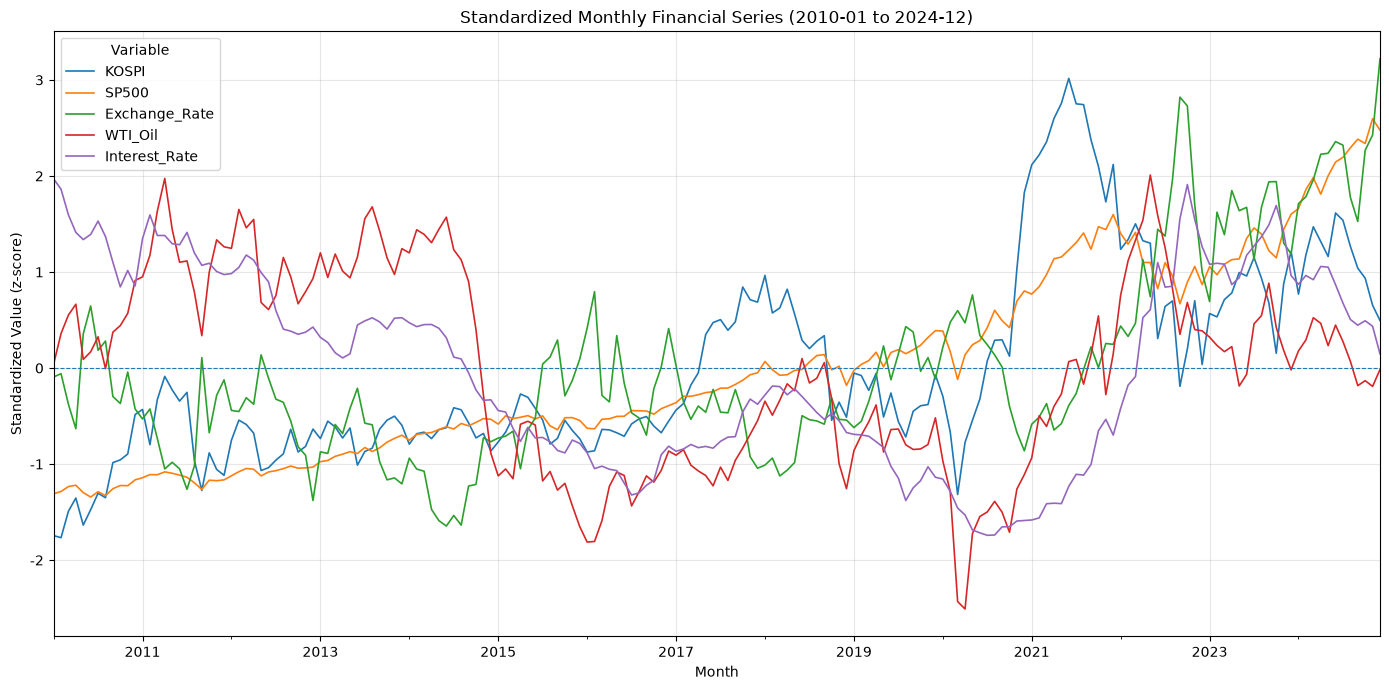

[SAVED] Standardized time-series figure: c:\Users\user\Desktop\주진호\05.ICT 인턴십\01.KOSPI\outputs\figures\monthly_series_standardized.png


In [11]:
standardized = (
    df_final - df_final.mean()
) / df_final.std(ddof=0)

standardized_figure_path = (
    fig_dir / "monthly_series_standardized.png"
)

fig, ax = plt.subplots(figsize=(14, 7))

standardized.plot(
    ax=ax,
    linewidth=1.2,
)

ax.axhline(
    y=0,
    linewidth=0.8,
    linestyle="--",
)

ax.set_title(
    "Standardized Monthly Financial Series "
    "(2010-01 to 2024-12)"
)

ax.set_xlabel("Month")
ax.set_ylabel("Standardized Value (z-score)")

ax.grid(
    True,
    alpha=0.3,
)

ax.legend(
    title="Variable",
    loc="best",
)

fig.tight_layout()

fig.savefig(
    standardized_figure_path,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print(
    f"[SAVED] Standardized time-series figure: "
    f"{standardized_figure_path}"
)